In [1]:
# Force-install compatible versions
!pip uninstall -y scikit-learn imbalanced-learn
!pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

Found existing installation: scikit-learn 1.3.2
Uninstalling scikit-learn-1.3.2:
  Successfully uninstalled scikit-learn-1.3.2
Found existing installation: imbalanced-learn 0.11.0
Uninstalling imbalanced-learn-0.11.0:
  Successfully uninstalled imbalanced-learn-0.11.0
  Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.11.0-py3-none-any.whl.metadata (8.3 kB)
Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.8 MB)
Using cached imbalanced_learn-0.11.0-py3-none-any.whl (235 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 0.12.2 requires scikit-learn>=1.4.1, but you have scikit-learn 1.3.2 which is incompatible.
nilearn 0.12.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
cesium 0.12

In [2]:
!pip install "protobuf<4.0.0" --upgrade

In [3]:
import os
import numpy as np
import scipy.io as sio
from scipy.signal import butter, filtfilt
from scipy.stats import kurtosis, skew
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# ==========================================
# 1. PREPROCESSING FUNCTIONS
# ==========================================

def bandpass_filter(data, lowcut=0.5, highcut=30, fs=250, order=5):
    """Optimized Butterworth bandpass filter"""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=-1)

def extract_p300_features(data):
    """Extract critical P300 features from time domain"""
    n_trials, n_channels, n_samples = data.shape
    features = []
    
    for trial in data:
        trial_features = []
        for channel in trial:
            # Time domain features
            trial_features.append(np.mean(channel))
            trial_features.append(np.std(channel))
            trial_features.append(np.max(channel))
            trial_features.append(np.min(channel))
            trial_features.append(kurtosis(channel))
            trial_features.append(skew(channel))
            
            # P300 window (250-500ms at 250Hz = samples 62-125)
            p300_window = channel[62:125]
            trial_features.append(np.mean(p300_window))
            trial_features.append(np.max(p300_window))
            trial_features.append(np.argmax(p300_window))
            
            # Early component (0-250ms)
            early = channel[0:62]
            trial_features.append(np.mean(early))
            
        features.append(trial_features)
    
    return np.array(features)

def preprocess_eeg(data):
    """Enhanced preprocessing pipeline"""
    data_original = data.copy()
    
    # Apply bandpass filter
    data = bandpass_filter(data, lowcut=0.5, highcut=30, fs=250, order=6)
    
    # Take first 8 channels and 250 samples
    data = data[:, :8, :250]
    
    # Robust normalization per trial per channel
    normalized = np.zeros_like(data)
    for i in range(len(data)):
        for j in range(8):
            channel = data[i, j, :]
            # Remove DC offset
            channel = channel - np.mean(channel)
            # Z-score normalization
            std = np.std(channel)
            if std > 1e-6:
                normalized[i, j, :] = channel / std
            else:
                normalized[i, j, :] = channel
                
    return normalized.astype(np.float32), data_original[:, :8, :250]

def load_data(sbj='SBJ01', sess='S01'):
    """Load and preprocess EEG data"""
    BASE_PATH = '/kaggle/input/bciaut-p300/data'
    path = os.path.join(BASE_PATH, sbj, sess, 'Train')
    X = sio.loadmat(os.path.join(path, 'trainData.mat'))['trainData']
    y = np.loadtxt(os.path.join(path, 'trainTargets.txt')).astype(np.int32)
    X = X.transpose(1, 0, 2) if X.shape[1] == len(y) else X.transpose(2, 0, 1)
    
    X_processed, X_raw = preprocess_eeg(X)
    return X_processed, y, X_raw

# ==========================================
# 2. DATA SHAPE & STATISTICS LOGGING
# ==========================================

def log_data_shapes(X_all, y_all, X_features, save_dir):
    """Log data shapes before and after preprocessing"""
    shape_log = {
        'timestamp': datetime.now().isoformat(),
        'raw_data': {
            'shape': str(X_all.shape),
            'dtype': str(X_all.dtype),
            'size_mb': X_all.nbytes / (1024**2)
        },
        'preprocessed_features': {
            'shape': str(X_features.shape),
            'dtype': str(X_features.dtype),
            'size_mb': X_features.nbytes / (1024**2)
        },
        'labels': {
            'shape': str(y_all.shape),
            'unique_classes': int(len(np.unique(y_all))),
            'class_distribution': {int(k): int(v) for k, v in zip(*np.unique(y_all, return_counts=True))}
        }
    }
    
    with open(save_dir + 'data_shapes_log.json', 'w') as f:
        json.dump(shape_log, f, indent=4)
    
    print("\n[DATA SHAPE LOG]")
    print(f"Raw Data Shape: {X_all.shape} | Size: {shape_log['raw_data']['size_mb']:.2f} MB")
    print(f"Feature Data Shape: {X_features.shape} | Size: {shape_log['preprocessed_features']['size_mb']:.2f} MB")
    print(f"Labels Shape: {y_all.shape}")
    print(f"Class Distribution: {shape_log['labels']['class_distribution']}")
    
    return shape_log

# ==========================================
# 3. VISUALIZATION FUNCTIONS
# ==========================================

def plot_sample_eeg_signals(X_raw, X_processed, save_dir, n_samples=3):
    """Plot raw vs processed EEG signals"""
    fig, axes = plt.subplots(n_samples, 2, figsize=(15, 12))
    fig.suptitle('Raw vs Processed EEG Signals', fontsize=16, fontweight='bold')
    
    for idx in range(n_samples):
        # Raw signal
        axes[idx, 0].plot(X_raw[idx, 0, :], alpha=0.7, linewidth=0.8)
        axes[idx, 0].set_title(f'Raw Signal - Trial {idx+1} (Channel 1)')
        axes[idx, 0].set_xlabel('Samples')
        axes[idx, 0].set_ylabel('Amplitude (µV)')
        axes[idx, 0].grid(True, alpha=0.3)
        
        # Processed signal
        axes[idx, 1].plot(X_processed[idx, 0, :], alpha=0.7, linewidth=0.8, color='orange')
        axes[idx, 1].set_title(f'Processed Signal - Trial {idx+1} (Channel 1)')
        axes[idx, 1].set_xlabel('Samples')
        axes[idx, 1].set_ylabel('Normalized Amplitude')
        axes[idx, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_dir + 'eeg_raw_vs_processed.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved eeg_raw_vs_processed.png")
    plt.close()

def plot_class_distribution(y_all, save_dir):
    """Plot class distribution"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')
    
    unique, counts = np.unique(y_all, return_counts=True)
    
    # Bar plot
    axes[0].bar(unique, counts, color=['#FF6B6B', '#4ECDC4'], alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Class', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Class Count')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Pie chart
    axes[1].pie(counts, labels=[f'Class {c}' for c in unique], autopct='%1.1f%%',
                colors=['#FF6B6B', '#4ECDC4'], startangle=90)
    axes[1].set_title('Class Distribution (%)')
    
    plt.tight_layout()
    plt.savefig(save_dir + 'class_distribution.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved class_distribution.png")
    plt.close()

def plot_feature_distributions(X_features, y_all, save_dir):
    """Plot feature distributions across classes"""
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    fig.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
    axes = axes.flatten()
    
    feature_names = ['Mean', 'Std', 'Max', 'Min', 'Kurtosis', 'Skew', 'P300_Mean', 'P300_Max', 'P300_ArgMax', 'Early_Mean']
    
    for feat_idx in range(min(10, X_features.shape[1])):
        class_0 = X_features[y_all == 0, feat_idx]
        class_1 = X_features[y_all == 1, feat_idx]
        
        axes[feat_idx].hist(class_0, bins=20, alpha=0.6, label='Class 0', color='#FF6B6B')
        axes[feat_idx].hist(class_1, bins=20, alpha=0.6, label='Class 1', color='#4ECDC4')
        axes[feat_idx].set_title(f'Feature {feat_idx}: {feature_names[feat_idx % 10]}')
        axes[feat_idx].set_xlabel('Value')
        axes[feat_idx].set_ylabel('Frequency')
        axes[feat_idx].legend()
        axes[feat_idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_dir + 'feature_distributions.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved feature_distributions.png")
    plt.close()

def plot_spectral_comparison(X_raw, X_processed, save_dir, n_samples=2):
    """Plot FFT comparison of raw vs processed signals"""
    fig, axes = plt.subplots(n_samples, 2, figsize=(14, 10))
    fig.suptitle('Frequency Domain: Raw vs Processed Signals (FFT)', fontsize=14, fontweight='bold')
    
    for idx in range(n_samples):
        # Raw FFT
        fft_raw = np.abs(np.fft.fft(X_raw[idx, 0, :]))
        freqs = np.fft.fftfreq(len(fft_raw), d=1/250)
        axes[idx, 0].plot(freqs[:len(freqs)//2], fft_raw[:len(fft_raw)//2])
        axes[idx, 0].set_title(f'Raw Signal FFT - Trial {idx+1}')
        axes[idx, 0].set_xlabel('Frequency (Hz)')
        axes[idx, 0].set_ylabel('Magnitude')
        axes[idx, 0].grid(True, alpha=0.3)
        axes[idx, 0].set_xlim([0, 40])
        
        # Processed FFT
        fft_proc = np.abs(np.fft.fft(X_processed[idx, 0, :]))
        axes[idx, 1].plot(freqs[:len(freqs)//2], fft_proc[:len(fft_proc)//2], color='orange')
        axes[idx, 1].set_title(f'Processed Signal FFT - Trial {idx+1}')
        axes[idx, 1].set_xlabel('Frequency (Hz)')
        axes[idx, 1].set_ylabel('Magnitude')
        axes[idx, 1].grid(True, alpha=0.3)
        axes[idx, 1].set_xlim([0, 40])
    
    plt.tight_layout()
    plt.savefig(save_dir + 'spectral_comparison_fft.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved spectral_comparison_fft.png")
    plt.close()

def plot_channel_heatmaps(X_processed, y_all, save_dir):
    """Plot heatmaps of signal amplitudes across channels"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('EEG Signal Heatmaps by Class', fontsize=14, fontweight='bold')
    
    for class_idx, class_label in enumerate([0, 1]):
        class_data = X_processed[y_all == class_label]
        # Average across trials
        avg_signal = np.mean(class_data, axis=0)
        
        im = axes[class_idx].imshow(avg_signal, aspect='auto', cmap='RdYlBu_r', interpolation='bilinear')
        axes[class_idx].set_title(f'Average Signal - Class {class_label}')
        axes[class_idx].set_xlabel('Time Samples')
        axes[class_idx].set_ylabel('Channel')
        axes[class_idx].set_yticks(range(8))
        plt.colorbar(im, ax=axes[class_idx], label='Normalized Amplitude')
    
    plt.tight_layout()
    plt.savefig(save_dir + 'channel_heatmaps.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved channel_heatmaps.png")
    plt.close()

def plot_statistics_summary(X_all, X_processed, save_dir):
    """Plot statistics before and after preprocessing"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Data Statistics: Before vs After Preprocessing', fontsize=14, fontweight='bold')
    
    stats_raw = {'mean': np.mean(X_all), 'std': np.std(X_all), 'max': np.max(X_all),
                 'min': np.min(X_all), 'median': np.median(X_all)}
    stats_proc = {'mean': np.mean(X_processed), 'std': np.std(X_processed), 'max': np.max(X_processed),
                  'min': np.min(X_processed), 'median': np.median(X_processed)}
    
    stat_names = list(stats_raw.keys())
    raw_vals = list(stats_raw.values())
    proc_vals = list(stats_proc.values())
    
    x = np.arange(len(stat_names))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, raw_vals, width, label='Raw', alpha=0.7, color='#FF6B6B')
    axes[0, 0].bar(x + width/2, proc_vals, width, label='Processed', alpha=0.7, color='#4ECDC4')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(stat_names)
    axes[0, 0].set_ylabel('Value')
    axes[0, 0].set_title('Overall Statistics')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Per-channel statistics
    raw_std_per_ch = np.std(np.mean(X_all, axis=(0, 2)), axis=0)
    proc_std_per_ch = np.std(np.mean(X_processed, axis=(0, 2)), axis=0)
    
    axes[0, 1].plot(raw_std_per_ch, marker='o', label='Raw', linewidth=2)
    axes[0, 1].plot(proc_std_per_ch, marker='s', label='Processed', linewidth=2)
    axes[0, 1].set_xlabel('Channel')
    axes[0, 1].set_ylabel('Std Dev')
    axes[0, 1].set_title('Std Dev per Channel')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Data range
    axes[0, 2].text(0.5, 0.7, f"Raw Data Range: [{stats_raw['min']:.2f}, {stats_raw['max']:.2f}]",
                    ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='#FF6B6B', alpha=0.3))
    axes[0, 2].text(0.5, 0.4, f"Processed Data Range: [{stats_proc['min']:.2f}, {stats_proc['max']:.2f}]",
                    ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='#4ECDC4', alpha=0.3))
    axes[0, 2].axis('off')
    
    # Histogram comparisons
    axes[1, 0].hist(X_all.flatten(), bins=50, alpha=0.7, color='#FF6B6B', label='Raw')
    axes[1, 0].set_title('Raw Signal Distribution')
    axes[1, 0].set_xlabel('Amplitude')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].hist(X_processed.flatten(), bins=50, alpha=0.7, color='#4ECDC4', label='Processed')
    axes[1, 1].set_title('Processed Signal Distribution')
    axes[1, 1].set_xlabel('Normalized Amplitude')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, alpha=0.3)
    
    axes[1, 2].text(0.5, 0.5, f"Data Shape Reduction:\n{X_all.shape} → {X_processed.shape}",
                    ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(save_dir + 'statistics_summary.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved statistics_summary.png")
    plt.close()

# ==========================================
# 2. MODEL ARCHITECTURE
# ==========================================

def squeeze_excite_block(input_tensor, ratio=8):
    """Channel attention mechanism"""
    filters = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1, 1, filters))(se)
    se = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal')(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal')(se)
    return Multiply()([input_tensor, se])

def build_hybrid_model():
    """Hybrid CNN + Handcrafted Features Model"""
    # CNN pathway
    cnn_input = Input(shape=(8, 250, 1), name='cnn_input')
    
    x = Conv2D(40, (1, 50), padding='same')(cnn_input)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    
    x = DepthwiseConv2D((8, 1), depth_multiplier=2, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4))(x)
    x = Dropout(0.5)(x)
    
    x = SeparableConv2D(80, (1, 16), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 8))(x)
    x = Dropout(0.5)(x)
    
    x = Flatten()(x)
    cnn_features = Dense(128, activation='relu')(x)
    
    # Feature pathway
    feature_input = Input(shape=(80,), name='feature_input')
    feature_dense = Dense(64, activation='relu')(feature_input)
    feature_dense = Dropout(0.3)(feature_dense)
    
    # Combine
    combined = Concatenate()([cnn_features, feature_dense])
    combined = Dense(128, activation='relu')(combined)
    combined = Dropout(0.5)(combined)
    combined = Dense(64, activation='relu')(combined)
    combined = Dropout(0.5)(combined)
    
    output = Dense(2, activation='softmax')(combined)
    
    model = Model(inputs=[cnn_input, feature_input], outputs=output)
    return model

# ==========================================
# 3. TRAINING PIPELINE
# ==========================================

print("="*70)
print("PART 1: MODEL TRAINING & DATA PREPROCESSING")
print("="*70)

print("\n[1/5] Loading and preprocessing data...")
X_all, y_all, X_raw = load_data()

X_features = extract_p300_features(X_all)

# Normalize features
scaler = StandardScaler()
X_features = scaler.fit_transform(X_features)

print(f"✓ Data shape: {X_all.shape}")
print(f"✓ Feature shape: {X_features.shape}")
print(f"✓ Class distribution: {np.bincount(y_all)}")

# Create save directory
save_dir = '/kaggle/working/'
os.makedirs(save_dir, exist_ok=True)

# Log data shapes
print("\n[2/5] Logging data shapes and creating visualizations...")
shape_log = log_data_shapes(X_all, y_all, X_features, save_dir)

# Save preprocessed data
print("\nSaving preprocessed data...")
np.save(save_dir + 'X_train_processed.npy', X_all)
np.save(save_dir + 'X_train_raw.npy', X_raw)
np.save(save_dir + 'y_train.npy', y_all)
np.save(save_dir + 'X_features.npy', X_features)
pickle.dump(scaler, open(save_dir + 'feature_scaler.pkl', 'wb'))
print(f"✓ Saved preprocessed data files")

# Generate visualizations
print("\nGenerating data visualizations...")
plot_sample_eeg_signals(X_raw, X_all, save_dir, n_samples=3)
plot_class_distribution(y_all, save_dir)
plot_feature_distributions(X_features, y_all, save_dir)
plot_spectral_comparison(X_raw, X_all, save_dir, n_samples=2)
plot_channel_heatmaps(X_all, y_all, save_dir)
plot_statistics_summary(X_raw, X_all, save_dir)

# Cross-validation & Training
print("\n[3/5] Training 10-Fold Ensemble...")

n_folds = 10
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

all_models = []
all_histories = []
fold_scores = []
fold_predictions = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
    print(f"  Fold {fold + 1}/{n_folds}...", end=' ')
    
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    X_feat_train, X_feat_val = X_features[train_idx], X_features[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]
    
    # Apply SMOTE
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_train_flat = X_train.reshape(len(X_train), -1)
    X_combined = np.hstack([X_train_flat, X_feat_train])
    X_resampled, y_resampled = smote.fit_resample(X_combined, y_train)
    
    X_cnn_resampled = X_resampled[:, :-80].reshape(-1, 8, 250, 1)
    X_feat_resampled = X_resampled[:, -80:]
    
    # Build model
    model = build_hybrid_model()
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=7, min_lr=1e-7, mode='max')
    ]
    
    # Train
    history = model.fit(
        [X_cnn_resampled, X_feat_resampled], 
        y_resampled,
        validation_data=([X_val.reshape(-1, 8, 250, 1), X_feat_val], y_val),
        epochs=100,
        batch_size=32,
        callbacks=callbacks,
        verbose=0,
        class_weight={0: 1.0, 1: 5.0}
    )
    
    # Evaluate
    val_pred = model.predict([X_val.reshape(-1, 8, 250, 1), X_feat_val], verbose=0)
    val_acc = accuracy_score(y_val, np.argmax(val_pred, axis=1))
    fold_scores.append(val_acc)
    
    all_models.append(model)
    all_histories.append(history)
    fold_predictions.append(val_pred)
    
    print(f"Acc: {val_acc*100:.2f}%")

print(f"\n✓ Mean CV Accuracy: {np.mean(fold_scores)*100:.2f}% ± {np.std(fold_scores)*100:.2f}%")

# Save models and histories
print("\n[4/5] Saving trained models...")

for fold, model in enumerate(all_models):
    model.save(save_dir + f'model_fold_{fold}.h5')
    print(f"✓ Saved model_fold_{fold}.h5")

pickle.dump(all_histories, open(save_dir + 'all_histories.pkl', 'wb'))
print(f"✓ Saved all_histories.pkl")

# Ensemble prediction
print("\n[5/5] Computing ensemble predictions...")

all_predictions = []
for model in all_models:
    pred = model.predict([X_all.reshape(-1, 8, 250, 1), X_features], verbose=0)
    all_predictions.append(pred)

weights = np.array(fold_scores)
weights = weights / weights.sum()

ensemble_probs = np.zeros_like(all_predictions[0])
for i, pred in enumerate(all_predictions):
    ensemble_probs += weights[i] * pred

# Find optimal threshold
final_probs = ensemble_probs[:, 1]
thresholds = np.linspace(0.1, 0.9, 500)
accuracies = [accuracy_score(y_all, (final_probs >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(accuracies)]
final_predictions = (final_probs >= best_threshold).astype(int)

print(f"✓ Optimal threshold: {best_threshold:.4f}")

# Save predictions and metadata
np.save(save_dir + 'final_predictions.npy', final_predictions)
np.save(save_dir + 'final_probabilities.npy', final_probs)
np.save(save_dir + 'ensemble_weights.npy', weights)
np.save(save_dir + 'fold_scores.npy', np.array(fold_scores))

metadata = {
    'n_folds': n_folds,
    'best_threshold': float(best_threshold),
    'mean_cv_accuracy': float(np.mean(fold_scores)),
    'std_cv_accuracy': float(np.std(fold_scores)),
    'fold_scores': fold_scores
}

with open(save_dir + 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"✓ Saved final_predictions.npy")
print(f"✓ Saved final_probabilities.npy")
print(f"✓ Saved ensemble_weights.npy")
print(f"✓ Saved metadata.json")

print("\n" + "="*70)
print("✓ PART 1 COMPLETE - All data and models saved successfully!")
print("="*70)

2026-01-14 00:29:35.438578: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768350575.459826    8833 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768350575.466303    8833 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768350575.483544    8833 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768350575.483572    8833 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768350575.483575    8833 computation_placer.cc:177] computation placer alr

PART 1: MODEL TRAINING & DATA PREPROCESSING

[1/5] Loading and preprocessing data...
✓ Data shape: (1600, 8, 250)
✓ Feature shape: (1600, 80)
✓ Class distribution: [1400  200]

[2/5] Logging data shapes and creating visualizations...

[DATA SHAPE LOG]
Raw Data Shape: (1600, 8, 250) | Size: 12.21 MB
Feature Data Shape: (1600, 80) | Size: 0.98 MB
Labels Shape: (1600,)
Class Distribution: {0: 1400, 1: 200}

Saving preprocessed data...
✓ Saved preprocessed data files

Generating data visualizations...
✓ Saved eeg_raw_vs_processed.png
✓ Saved class_distribution.png
✓ Saved feature_distributions.png
✓ Saved spectral_comparison_fft.png
✓ Saved channel_heatmaps.png
✓ Saved statistics_summary.png

[3/5] Training 10-Fold Ensemble...
  Fold 1/10... 

I0000 00:00:1768350607.817758    8833 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768350607.821642    8833 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1768350613.430397    8913 service.cc:152] XLA service 0x7db240017ac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768350613.430430    8913 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768350613.430434    8913 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768350613.984062    8913 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1768350619.921475    8913 device_compiler.h:188] Compiled clust

Acc: 89.38%
  Fold 2/10... Acc: 85.62%
  Fold 3/10... Acc: 86.25%
  Fold 4/10... Acc: 86.88%
  Fold 5/10... Acc: 90.00%
  Fold 6/10... Acc: 81.88%
  Fold 7/10... Acc: 87.50%
  Fold 8/10... Acc: 87.50%
  Fold 9/10... Acc: 83.75%
  Fold 10/10... 

Acc: 87.50%

✓ Mean CV Accuracy: 86.63% ± 2.31%

[4/5] Saving trained models...
✓ Saved model_fold_0.h5
✓ Saved model_fold_1.h5


✓ Saved model_fold_2.h5
✓ Saved model_fold_3.h5
✓ Saved model_fold_4.h5
✓ Saved model_fold_5.h5


✓ Saved model_fold_6.h5
✓ Saved model_fold_7.h5
✓ Saved model_fold_8.h5
✓ Saved model_fold_9.h5
✓ Saved all_histories.pkl

[5/5] Computing ensemble predictions...
✓ Optimal threshold: 0.6948
✓ Saved final_predictions.npy
✓ Saved final_probabilities.npy
✓ Saved ensemble_weights.npy
✓ Saved metadata.json

✓ PART 1 COMPLETE - All data and models saved successfully!


Test


PART 2: LOAD MODELS & GENERATE VISUALIZATIONS

[1/11] Loading saved data...
✓ Loaded data shapes: (1600, 8, 250), (1600,)
✓ Best threshold: 0.6948

[2/11] Loading trained models...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 24 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✓ Loaded 10 models

[3/11] Loading training histories...
✓ Loaded 10 training histories

[4/11] Creating preprocessing visualization...
✓ Saved: 01_preprocessing_raw_vs_processed.png
✓ Saved: 02_preprocessing_multiple_trials.png
✓ Saved: 03_preprocessing_statistical_comparison.png

[5/11] Creating training history visualizations...
✓ Saved: 04_training_validation_accuracy.png
✓ Saved: 05_training_loss_history.png
✓ Saved: 06_fold_scores.png

[6/11] Creating classification metric visualizations...
✓ Saved: 07_confusion_matrix.png
✓ Saved: 08_roc_curve.png
✓ Saved: 09_precision_recall_curve.png
✓ Saved: 10_performance_metrics.png

[7/11] Creating ERP waveform visualizations...
✓ Saved: 11_erp_grand_average.png
✓ Saved: 12_channel_wise_erp.png

[8/11] Creating spatial-temporal visualizations...
✓ Saved: 13_spatial_temporal_3d.png
✓ Saved: 14_spatial_temporal_heatmap.png
✓ Saved: 15_difference_map.png

[9/11] Creating probability distribution visualizations...
✓ Saved: 16_probability_distr

<bound method Axes.set of <Axes: >>

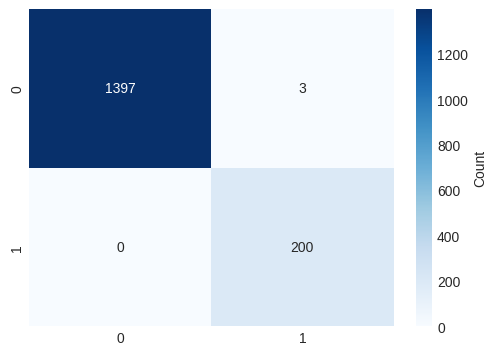

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy.fft import fft, fftfreq
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, 
    f1_score, balanced_accuracy_score, matthews_corrcoef, roc_curve, 
    roc_auc_score, precision_recall_curve, average_precision_score,
    classification_report
)
import tensorflow as tf
import pickle
import json

# ==========================================
# CONFIGURATION
# ==========================================

load_dir = '/kaggle/working/'
save_dir = '/kaggle/working/visualizations/'
os.makedirs(save_dir, exist_ok=True)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("PART 2: LOAD MODELS & GENERATE VISUALIZATIONS")
print("="*70)

# ==========================================
# 1. LOAD ALL DATA AND MODELS
# ==========================================

print("\n[1/11] Loading saved data...")

X_all = np.load(load_dir + 'X_train_processed.npy')
X_raw = np.load(load_dir + 'X_train_raw.npy')
y_all = np.load(load_dir + 'y_train.npy')
X_features = np.load(load_dir + 'X_features.npy')
final_predictions = np.load(load_dir + 'final_predictions.npy')
final_probs = np.load(load_dir + 'final_probabilities.npy')
ensemble_weights = np.load(load_dir + 'ensemble_weights.npy')
fold_scores = np.load(load_dir + 'fold_scores.npy')

with open(load_dir + 'metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"✓ Loaded data shapes: {X_all.shape}, {y_all.shape}")
print(f"✓ Best threshold: {metadata['best_threshold']:.4f}")

print("\n[2/11] Loading trained models...")

all_models = []
n_folds = metadata['n_folds']

for fold in range(n_folds):
    model = tf.keras.models.load_model(load_dir + f'model_fold_{fold}.h5')
    all_models.append(model)

print(f"✓ Loaded {len(all_models)} models")

print("\n[3/11] Loading training histories...")

with open(load_dir + 'all_histories.pkl', 'rb') as f:
    all_histories = pickle.load(f)

print(f"✓ Loaded {len(all_histories)} training histories")

# ==========================================
# 2. PREPROCESSING VISUALIZATION
# ==========================================

print("\n[4/11] Creating preprocessing visualization...")

np.random.seed(42)
sample_indices = np.random.choice(len(X_raw), min(5, len(X_raw)), replace=False)

# Raw vs Processed - Single Trial All Channels
fig, axes = plt.subplots(8, 2, figsize=(14, 16))
trial_idx = sample_indices[0]

for ch in range(8):
    axes[ch, 0].plot(X_raw[trial_idx, ch, :], 'b-', linewidth=1, alpha=0.7)
    axes[ch, 0].set_ylabel(f'Ch {ch+1}', fontweight='bold')
    axes[ch, 0].grid(alpha=0.3)
    if ch == 0:
        axes[ch, 0].set_title('Raw Signal', fontsize=14, fontweight='bold')
    if ch == 7:
        axes[ch, 0].set_xlabel('Samples')
    
    axes[ch, 1].plot(X_all[trial_idx, ch, :], 'r-', linewidth=1, alpha=0.7)
    axes[ch, 1].set_ylabel(f'Ch {ch+1}', fontweight='bold')
    axes[ch, 1].grid(alpha=0.3)
    if ch == 0:
        axes[ch, 1].set_title('Preprocessed Signal', fontsize=14, fontweight='bold')
    if ch == 7:
        axes[ch, 1].set_xlabel('Samples')

plt.suptitle('Signal Preprocessing - Single Trial (All Channels)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(save_dir + '01_preprocessing_raw_vs_processed.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 01_preprocessing_raw_vs_processed.png")

# Multiple Trials - Single Channel
fig, axes = plt.subplots(len(sample_indices), 2, figsize=(14, 10))
ch_display = 2

for i, idx in enumerate(sample_indices):
    axes[i, 0].plot(X_raw[idx, ch_display, :], 'b-', linewidth=1.5, alpha=0.7)
    axes[i, 0].set_ylabel(f'Trial {i+1}', fontweight='bold')
    axes[i, 0].grid(alpha=0.3)
    if i == 0:
        axes[i, 0].set_title('Raw Signal (Channel 3)', fontsize=14, fontweight='bold')
    if i == len(sample_indices) - 1:
        axes[i, 0].set_xlabel('Samples')
    
    axes[i, 1].plot(X_all[idx, ch_display, :], 'r-', linewidth=1.5, alpha=0.7)
    axes[i, 1].set_ylabel(f'Trial {i+1}', fontweight='bold')
    axes[i, 1].grid(alpha=0.3)
    if i == 0:
        axes[i, 1].set_title('Preprocessed Signal (Channel 3)', fontsize=14, fontweight='bold')
    if i == len(sample_indices) - 1:
        axes[i, 1].set_xlabel('Samples')

plt.suptitle('Signal Preprocessing - Multiple Trials (Channel 3)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(save_dir + '02_preprocessing_multiple_trials.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 02_preprocessing_multiple_trials.png")

# Statistical Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(np.mean(X_raw, axis=(1, 2)), bins=50, alpha=0.7, color='blue', label='Raw', edgecolor='black')
axes[0, 0].hist(np.mean(X_all, axis=(1, 2)), bins=50, alpha=0.7, color='red', label='Processed', edgecolor='black')
axes[0, 0].set_xlabel('Mean Amplitude')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Mean Amplitude', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].hist(np.std(X_raw, axis=(1, 2)), bins=50, alpha=0.7, color='blue', label='Raw', edgecolor='black')
axes[0, 1].hist(np.std(X_all, axis=(1, 2)), bins=50, alpha=0.7, color='red', label='Processed', edgecolor='black')
axes[0, 1].set_xlabel('Standard Deviation')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Standard Deviation', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(np.max(X_raw, axis=(1, 2)) - np.min(X_raw, axis=(1, 2)), bins=50, alpha=0.7, color='blue', label='Raw', edgecolor='black')
axes[1, 0].hist(np.max(X_all, axis=(1, 2)) - np.min(X_all, axis=(1, 2)), bins=50, alpha=0.7, color='red', label='Processed', edgecolor='black')
axes[1, 0].set_xlabel('Amplitude Range (Max - Min)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Amplitude Range', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

trial_raw = X_raw[sample_indices[0], 2, :]
trial_proc = X_all[sample_indices[0], 2, :]
fft_raw = np.abs(fft(trial_raw))[:125]
fft_proc = np.abs(fft(trial_proc))[:125]
freqs = fftfreq(250, 1/250)[:125]

axes[1, 1].plot(freqs, fft_raw, 'b-', linewidth=2, alpha=0.7, label='Raw')
axes[1, 1].plot(freqs, fft_proc, 'r-', linewidth=2, alpha=0.7, label='Processed')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('Magnitude')
axes[1, 1].set_title('Frequency Spectrum (Sample Trial)', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlim(0, 50)

plt.suptitle('Statistical Comparison: Raw vs Preprocessed Data', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(save_dir + '03_preprocessing_statistical_comparison.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 03_preprocessing_statistical_comparison.png")

# ==========================================
# 3. TRAINING HISTORY VISUALIZATIONS
# ==========================================

print("\n[5/11] Creating training history visualizations...")

# Validation Accuracy across folds
fig, ax = plt.subplots(figsize=(12, 7))
for i, h in enumerate(all_histories):
    ax.plot(h.history['val_accuracy'], alpha=0.6, linewidth=2.5, label=f'Fold {i+1}')
ax.axhline(y=np.mean(fold_scores), color='red', linestyle='--', linewidth=3, label=f'Mean: {np.mean(fold_scores)*100:.2f}%')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Training Progress - Validation Accuracy Across Folds', fontsize=14, fontweight='bold')
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir + '04_training_validation_accuracy.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 04_training_validation_accuracy.png")

# Training and Validation Loss
fig, ax = plt.subplots(figsize=(12, 7))
for i, h in enumerate(all_histories):
    if 'loss' in h.history:
        ax.plot(h.history['loss'], alpha=0.3, linewidth=1.5, label=f'Fold {i+1} Train')
        ax.plot(h.history['val_loss'], alpha=0.7, linewidth=2, linestyle='--', label=f'Fold {i+1} Val')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(ncol=4, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir + '05_training_loss_history.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 05_training_loss_history.png")

# Fold Scores Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, n_folds))
bars = ax.bar(range(1, n_folds+1), fold_scores, color=colors, edgecolor='black', linewidth=2)
ax.axhline(y=np.mean(fold_scores), color='red', linestyle='--', linewidth=3, 
           label=f'Mean: {np.mean(fold_scores)*100:.2f}%')
ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Validation Accuracy Per Fold', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

for bar, score in zip(bars, fold_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{score*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(save_dir + '06_fold_scores.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 06_fold_scores.png")

# ==========================================
# 4. CLASSIFICATION METRICS
# ==========================================

print("\n[6/11] Creating classification metric visualizations...")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(9, 8))
cm = confusion_matrix(y_all, final_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'}, 
            ax=ax, annot_kws={'size': 14, 'weight': 'bold'})
acc = accuracy_score(y_all, final_predictions)
ax.set_title(f'Confusion Matrix\nAccuracy: {acc*100:.2f}%', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_xticklabels(['Non-Target', 'Target'])
ax.set_yticklabels(['Non-Target', 'Target'])
plt.tight_layout()
plt.savefig(save_dir + '07_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 07_confusion_matrix.png")

# ROC Curve
fig, ax = plt.subplots(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_all, final_probs)
auc = roc_auc_score(y_all, final_probs)
ax.plot(fpr, tpr, 'b-', linewidth=4, label=f'AUC = {auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=2, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2)
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Ensemble Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir + '08_roc_curve.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 08_roc_curve.png")

# Precision-Recall Curve
fig, ax = plt.subplots(figsize=(10, 8))
precision, recall, _ = precision_recall_curve(y_all, final_probs)
ap = average_precision_score(y_all, final_probs)
ax.plot(recall, precision, 'r-', linewidth=4, label=f'AP = {ap:.4f}')
ax.fill_between(recall, precision, alpha=0.2, color='red')
ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(save_dir + '09_precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 09_precision_recall_curve.png")

# Performance Metrics Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
metrics = {
    'Accuracy': accuracy_score(y_all, final_predictions),
    'Precision': precision_score(y_all, final_predictions),
    'Recall': recall_score(y_all, final_predictions),
    'F1-Score': f1_score(y_all, final_predictions),
    'Balanced Acc': balanced_accuracy_score(y_all, final_predictions),
    'MCC': matthews_corrcoef(y_all, final_predictions)
}
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(metrics)))
bars = ax.bar(range(len(metrics)), list(metrics.values()), color=colors, 
              edgecolor='black', linewidth=2.5)
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(list(metrics.keys()), rotation=45, ha='right', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Classification Performance Metrics', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, (name, val) in zip(bars, metrics.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(save_dir + '10_performance_metrics.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 10_performance_metrics.png")

# ==========================================
# 5. ERP WAVEFORMS
# ==========================================

print("\n[7/11] Creating ERP waveform visualizations...")

# Grand Average ERP
fig, ax = plt.subplots(figsize=(12, 8))
target_avg = np.mean(X_all[y_all == 1], axis=(0, 1))
nontarget_avg = np.mean(X_all[y_all == 0], axis=(0, 1))
target_std = np.std(np.mean(X_all[y_all == 1], axis=1), axis=0)
nontarget_std = np.std(np.mean(X_all[y_all == 0], axis=1), axis=0)

time_ms = np.arange(250) * 4
ax.plot(time_ms, target_avg, 'r-', linewidth=3.5, label='Target (P300)', zorder=3)
ax.fill_between(time_ms, target_avg - target_std, target_avg + target_std, 
                color='red', alpha=0.2)
ax.plot(time_ms, nontarget_avg, color='gray', linewidth=3.5, alpha=0.8, label='Non-Target', zorder=3)
ax.fill_between(time_ms, nontarget_avg - nontarget_std, nontarget_avg + nontarget_std, 
                color='gray', alpha=0.15)
ax.axvspan(250, 500, alpha=0.15, color='yellow', label='P300 Window', zorder=1)
ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
ax.set_ylabel('Amplitude (μV)', fontsize=12, fontweight='bold')
ax.set_title('Grand Average ERP Waveforms', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir + '11_erp_grand_average.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 11_erp_grand_average.png")

# Channel-wise ERP
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for ch in range(8):
    target_ch = np.mean(X_all[y_all == 1][:, ch, :], axis=0)
    nontarget_ch = np.mean(X_all[y_all == 0][:, ch, :], axis=0)
    
    axes[ch].plot(time_ms, target_ch, 'r-', linewidth=2.5, label='Target')
    axes[ch].plot(time_ms, nontarget_ch, 'gray', linewidth=2.5, alpha=0.7, label='Non-Target')
    axes[ch].axvspan(250, 500, alpha=0.15, color='yellow')
    axes[ch].set_title(f'Channel {ch+1}', fontweight='bold', fontsize=11)
    axes[ch].grid(alpha=0.3)
    axes[ch].set_ylim(np.min(target_ch - 0.3), np.max(target_ch + 0.3))
    
    if ch >= 4:
        axes[ch].set_xlabel('Time (ms)', fontsize=10)
    if ch % 4 == 0:
        axes[ch].set_ylabel('Amplitude', fontsize=10)
    if ch == 0:
        axes[ch].legend(fontsize=9)

plt.suptitle('Channel-wise ERP Waveforms', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(save_dir + '12_channel_wise_erp.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 12_channel_wise_erp.png")

# ==========================================
# 6. SPATIAL-TEMPORAL VISUALIZATIONS
# ==========================================

print("\n[8/11] Creating spatial-temporal visualizations...")

# 3D Surface Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
p300_surface = np.mean(X_all[y_all == 1], axis=0)
X_mesh, Y_mesh = np.meshgrid(np.arange(250), np.arange(8))
surf = ax.plot_surface(X_mesh, Y_mesh, p300_surface, cmap='coolwarm', alpha=0.9, 
                       edgecolor='none', antialiased=True)
ax.set_xlabel('Time (samples)', fontsize=11, fontweight='bold')
ax.set_ylabel('Channel', fontsize=11, fontweight='bold')
ax.set_zlabel('Amplitude', fontsize=11, fontweight='bold')
ax.set_title('P300 Spatial-Temporal Surface', fontsize=14, fontweight='bold', pad=20)
cbar = fig.colorbar(surf, shrink=0.6, aspect=10)
cbar.set_label('Amplitude', fontweight='bold')
ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.savefig(save_dir + '13_spatial_temporal_3d.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 13_spatial_temporal_3d.png")

# Heatmap: Target responses
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(p300_surface, aspect='auto', cmap='RdBu_r', origin='lower', 
               interpolation='bilinear')
ax.set_xlabel('Time (samples)', fontsize=12, fontweight='bold')
ax.set_ylabel('Channel', fontsize=12, fontweight='bold')
ax.set_title('P300 Response - Spatial-Temporal Heatmap', fontsize=14, fontweight='bold')
ax.set_yticks(range(8))
ax.set_yticklabels([f'Ch {i+1}' for i in range(8)])
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Amplitude (μV)', fontweight='bold')
plt.tight_layout()
plt.savefig(save_dir + '14_spatial_temporal_heatmap.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 14_spatial_temporal_heatmap.png")

# Difference map (Target - Non-Target)
fig, ax = plt.subplots(figsize=(14, 6))
diff_surface = p300_surface - np.mean(X_all[y_all == 0], axis=0)
im = ax.imshow(diff_surface, aspect='auto', cmap='RdBu_r', origin='lower')
ax.set_xlabel('Time (samples)', fontsize=12, fontweight='bold')
ax.set_ylabel('Channel', fontsize=12, fontweight='bold')
ax.set_title('Target - Non-Target Difference Map', fontsize=14, fontweight='bold')
ax.set_yticks(range(8))
ax.set_yticklabels([f'Ch {i+1}' for i in range(8)])
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Amplitude Difference (μV)', fontweight='bold')
plt.tight_layout()
plt.savefig(save_dir + '15_difference_map.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 15_difference_map.png")

# ==========================================
# 7. PROBABILITY DISTRIBUTIONS
# ==========================================

print("\n[9/11] Creating probability distribution visualizations...")

# Histogram of predictions
fig, ax = plt.subplots(figsize=(12, 7))
ax.hist(final_probs[y_all == 0], bins=50, alpha=0.7, color='blue', edgecolor='black', 
        linewidth=1.5, label='Non-Target (actual)')
ax.hist(final_probs[y_all == 1], bins=50, alpha=0.7, color='red', edgecolor='black', 
        linewidth=1.5, label='Target (actual)')
ax.axvline(x=metadata['best_threshold'], color='green', linestyle='--', linewidth=3, 
           label=f'Decision Threshold ({metadata["best_threshold"]:.3f})')
ax.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(save_dir + '16_probability_distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 16_probability_distribution.png")

# Ensemble Weights
fig, ax = plt.subplots(figsize=(12, 7))
colors_weights = plt.cm.viridis(np.linspace(0.3, 0.9, n_folds))
bars = ax.bar(range(1, n_folds+1), ensemble_weights, color=colors_weights, 
              edgecolor='black', linewidth=2.5)
ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Ensemble Weight', fontsize=12, fontweight='bold')
ax.set_title('Ensemble Model Weights (Based on Fold Performance)', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

for bar, weight, score in zip(bars, ensemble_weights, fold_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{weight*100:.1f}%\n(Acc:{score*100:.1f}%)', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(save_dir + '17_ensemble_weights.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✓ Saved: 17_ensemble_weights.png")

# ==========================================
# 8. COMPREHENSIVE OVERVIEW
# ==========================================

print("\n[10/11] Creating comprehensive overview visualization...")

fig = plt.figure(figsize=(20, 14))

# 1. Confusion Matrix
ax1 = plt.subplot(3, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar_kws={'label': 'Count'})
ax1.set